# OptiCore - IV Analysis

This notebook digs into what actually moves option prices: implied volatility. We cover

1. The smile, expiry by expiry
2. Skew in one number - the 25-delta risk reversal
3. Term structure of ATM IV
4. Put-call parity as a no-arbitrage check
5. Implied forwards and the dividend yield hiding in the quotes
6. The mispricing screen

Everything runs **offline** on the sample chain that ships with the package - no broker
account, no API key, no network. For the same workflow on live data, see
`03_yfinance_tutorial.ipynb`.

## 0. Setup

In [1]:
import matplotlib.pyplot as plt
import opticore as oc
import pandas as pd

print(f"OptiCore version: {oc.__version__}")

OptiCore version: 0.2.0


## 1. Load and enrich the sample chain

`provider="sample"` returns an SPY-like chain bundled with the package: six expiries from
one week to about nine months out, with realistic skew and bid/ask spreads. `oc.enrich()`
adds `iv`, the five Greeks, `tte`, and the `theo_price` / `mispricing` sanity columns.

In [2]:
chain = oc.fetch_chain("SPY", provider="sample")
enriched = oc.enrich(chain, rate=0.045)

spot = chain["underlying_price"].iloc[0]
n_solved = enriched["iv"].notna().sum()
print(f"{len(enriched)} contracts, {enriched['expiry'].nunique()} expiries, spot ${spot:.2f}")
print(f"IV solved for {n_solved} of {len(enriched)} contracts")

enriched[["strike", "expiry", "kind", "mid", "iv", "delta", "vega"]].head(8)

372 contracts, 6 expiries, spot $510.00
IV solved for 344 of 372 contracts


,strike,expiry,kind,mid,iv,delta,vega
0,433.5,2026-06-13 20:44:38.097695+00:00,call,76.90,0.431153,0.997172,0.006124
1,433.5,2026-06-13 20:44:38.097695+00:00,put,0.01,0.394155,-0.001258,0.002933
2,438.5,2026-06-13 20:44:38.097695+00:00,call,71.67,NaN,NaN,NaN
3,438.5,2026-06-13 20:44:38.097695+00:00,put,0.01,0.368629,-0.001340,0.003107
4,443.5,2026-06-13 20:44:38.097695+00:00,call,66.99,0.442209,0.990015,0.018793
5,443.5,2026-06-13 20:44:38.097695+00:00,put,0.01,0.343274,-0.001432,0.003303
6,448.5,2026-06-13 20:44:38.097695+00:00,call,61.69,NaN,NaN,NaN
7,448.5,2026-06-13 20:44:38.097695+00:00,put,0.01,0.318075,-0.001539,0.003526


The contracts without an IV are deep-ITM and short-dated: their vega is near zero, so a
cent of quote noise puts the mid at (or through) the no-time-value floor and no vol can
reproduce it. The solver returns NaN instead of inventing a number
(see [ADR-0002](../docs/decisions/0002-nan-propagation-not-exceptions.md)).

## 2. The smile, expiry by expiry

In a flat Black-Scholes world IV would be one number per expiry. It is not: low strikes
trade rich because the market pays up for crash protection. Plotting each expiry on its
own axes shows the second effect - the smile flattens as maturity grows, because a fixed
% move matters less over a longer horizon.

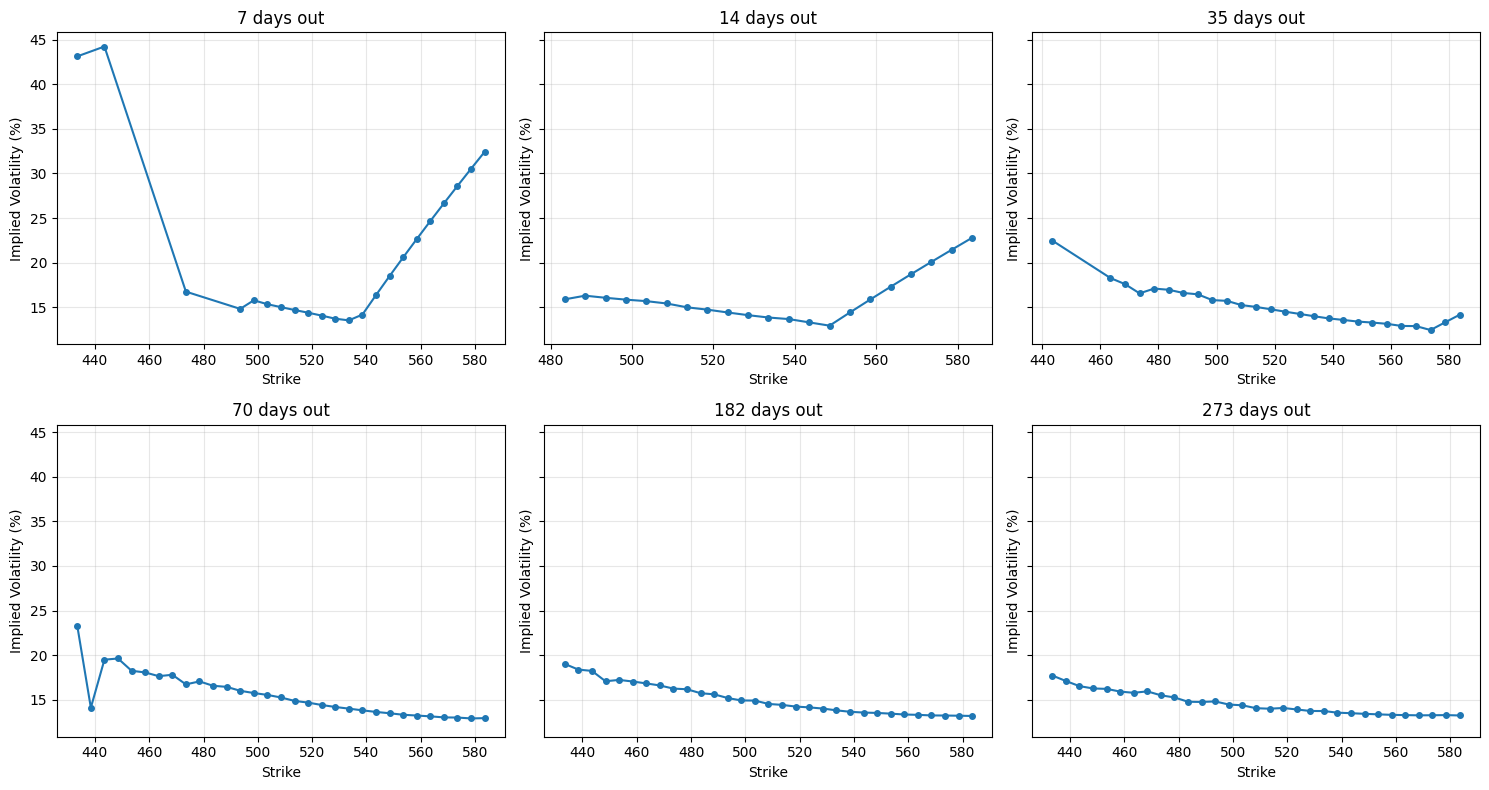

In [3]:
expiries = sorted(enriched["expiry"].unique())

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
for ax, exp in zip(axes.flat, expiries):
    sub = enriched[enriched["expiry"] == exp]
    oc.plot.smile(sub, expiry=exp, ax=ax)
    ax.set_title(f"{sub['tte'].iloc[0] * 365:.0f} days out")
    ax.get_legend().remove()
fig.tight_layout()
plt.show()

## 3. Skew in one number - the 25-delta risk reversal

Traders quote skew as the **risk reversal**: IV of the 25-delta put minus IV of the
25-delta call. Using delta instead of strike makes the number comparable across expiries
and underlyings. Positive RR25 = downside protection costs more than upside exposure.

In [4]:
rows = []
for exp, g in enriched.dropna(subset=["iv", "delta"]).groupby("expiry"):
    calls = g[g["kind"] == "call"]
    puts = g[g["kind"] == "put"]
    c25 = calls.iloc[(calls["delta"] - 0.25).abs().argmin()]
    p25 = puts.iloc[(puts["delta"] + 0.25).abs().argmin()]
    rows.append({
        "expiry": exp,
        "days": g["tte"].iloc[0] * 365,
        "put_25d_iv": p25["iv"],
        "call_25d_iv": c25["iv"],
        "rr25": p25["iv"] - c25["iv"],
    })

rr = pd.DataFrame(rows)
rr

,expiry,days,put_25d_iv,call_25d_iv,rr25
0,2026-06-13 20:44:38.097695+00:00,6.995209,0.159243,0.143875,0.015369
1,2026-06-20 20:44:38.097695+00:00,13.990418,0.168709,0.144134,0.024575
2,2026-07-11 20:44:38.097695+00:00,34.976044,0.177004,0.142508,0.034496
3,2026-08-15 20:44:38.097695+00:00,69.952088,0.182403,0.138121,0.044282
4,2026-12-05 20:44:38.097695+00:00,181.875428,0.185994,0.133471,0.052523
5,2027-03-06 20:44:38.097695+00:00,272.813142,0.188494,0.132632,0.055862


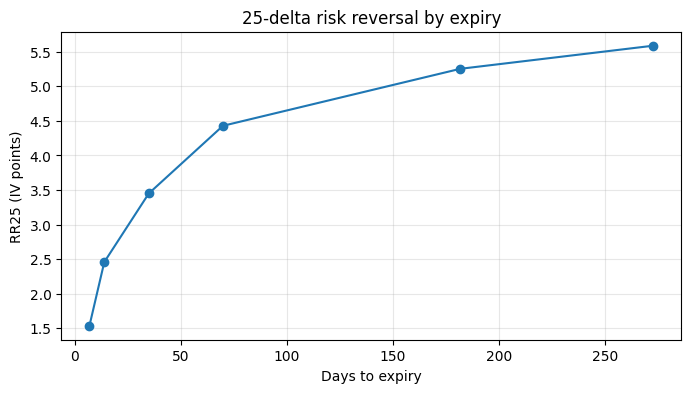

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(rr["days"], rr["rr25"] * 100, marker="o")
ax.set_xlabel("Days to expiry")
ax.set_ylabel("RR25 (IV points)")
ax.set_title("25-delta risk reversal by expiry")
ax.grid(True, alpha=0.3)
plt.show()

In this chain the risk reversal *grows* with maturity. Per-expiry smiles flatten (section 2)
but the 25-delta points sit further from ATM at longer maturities, so the put-call IV gap
widens. Both views are right - they just slice the same surface differently, which is why
quoting skew by delta and by strike can disagree.

## 4. Term structure of ATM IV

Now fix the strike at-the-money and walk the other axis of the surface. An upward-sloping
term structure is the calm-market default; an inverted one means the market expects
near-term turbulence (earnings, CPI prints, elections).

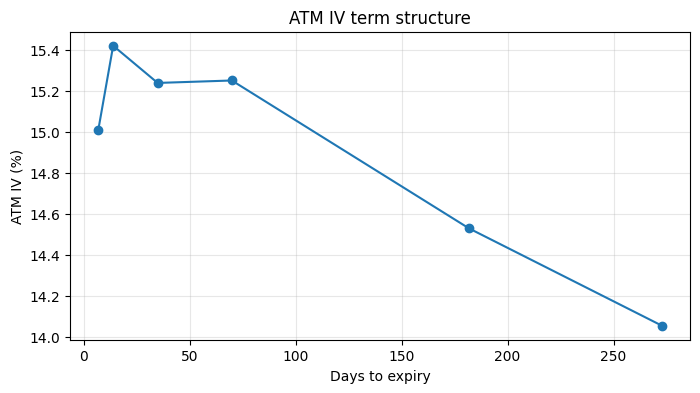

,expiry,strike,iv,tte
0,2026-06-13 20:44:38.097695+00:00,508.5,0.150117,0.019165
1,2026-06-20 20:44:38.097695+00:00,508.5,0.154222,0.038330
2,2026-07-11 20:44:38.097695+00:00,508.5,0.152403,0.095825
3,2026-08-15 20:44:38.097695+00:00,508.5,0.152522,0.191650
4,2026-12-05 20:44:38.097695+00:00,508.5,0.145287,0.498289
5,2027-03-06 20:44:38.097695+00:00,508.5,0.140532,0.747433


In [6]:
term = (
    enriched.dropna(subset=["iv"])
    .assign(dist=lambda d: (d["strike"] - d["underlying_price"]).abs())
    .sort_values(["expiry", "dist"])
    .groupby("expiry")
    .first()[["strike", "iv", "tte"]]
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(term["tte"] * 365, term["iv"] * 100, marker="o")
ax.set_xlabel("Days to expiry")
ax.set_ylabel("ATM IV (%)")
ax.set_title("ATM IV term structure")
ax.grid(True, alpha=0.3)
plt.show()

term

## 5. Put-call parity - the no-arbitrage check

Parity says `C - P = S e^(-qT) - K e^(-rT)` regardless of any model. `oc.parity_check()`
computes the residual from mid quotes for every strike with both a call and a put. Let's
run it with the defaults (no dividend yield):

In [7]:
pc = oc.parity_check(chain, rate=0.045)
print(f"strike/expiry pairs checked: {len(pc)}")
print(f"mean |residual|: {pc['parity_residual'].abs().mean():.3f}")
print(f"max  |residual|: {pc['parity_residual'].abs().max():.3f}")

strike/expiry pairs checked: 186
mean |residual|: 1.763
max  |residual|: 5.289


Dollar-sized residuals on a clean synthetic chain? That is not mispricing - we fed parity
the wrong carry. The chain embeds a dividend yield and we passed `div_yield=0`. Rather
than guessing the right value, back it out of the quotes.

## 6. Implied forwards

`oc.implied_forward()` solves parity for the forward price at the ATM strikes, where
quotes are tightest. The implied dividend yield falls out for free.

In [8]:
fwd = oc.implied_forward(chain, rate=0.045)
fwd

,expiry,tte,forward,implied_div_yield,n_strikes_used
0,2026-06-13 20:44:38.097695+00:00,0.019165,510.298217,0.014498,3
1,2026-06-20 20:44:38.097695+00:00,0.038330,510.610303,0.013798,3
2,2026-07-11 20:44:38.097695+00:00,0.095825,511.519660,0.013951,3
3,2026-08-15 20:44:38.097695+00:00,0.191650,513.136481,0.013009,3
4,2026-12-05 20:44:38.097695+00:00,0.498289,518.201789,0.012982,3
5,2027-03-06 20:44:38.097695+00:00,0.747433,522.134289,0.013540,3


In [9]:
q = fwd["implied_div_yield"].mean()
pc_q = oc.parity_check(chain, rate=0.045, div_yield=q)
print(f"implied dividend yield: {q:.4f}")
print(f"mean |residual|: {pc_q['parity_residual'].abs().mean():.3f}  "
      f"(was {pc['parity_residual'].abs().mean():.3f})")
print(f"max  |residual|: {pc_q['parity_residual'].abs().max():.3f}  "
      f"(was {pc['parity_residual'].abs().max():.3f})")

implied dividend yield: 0.0136
mean |residual|: 0.135  (was 1.763)
max  |residual|: 0.798  (was 5.289)


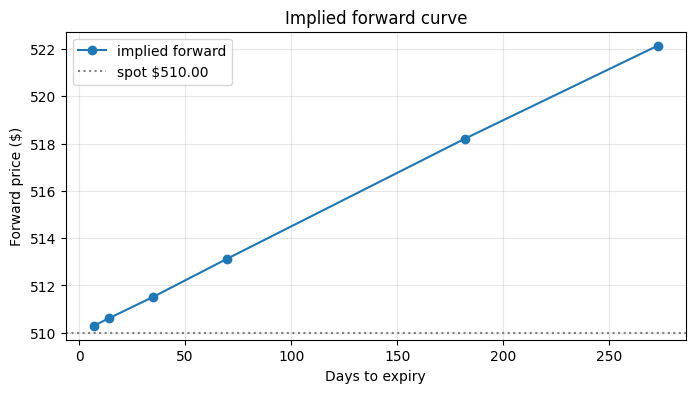

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(fwd["tte"] * 365, fwd["forward"], marker="o", label="implied forward")
ax.axhline(spot, color="gray", linestyle=":", label=f"spot ${spot:.2f}")
ax.set_xlabel("Days to expiry")
ax.set_ylabel("Forward price ($)")
ax.set_title("Implied forward curve")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

The forward sits above spot and drifts up with maturity: rates (4.5%) outweigh the
dividend yield (~1.3%), so carry is positive. The leftover residuals are bid/ask noise,
an order of magnitude smaller than before.

## 7. The mispricing screen

`oc.enrich()` already added `theo_price` (the BSM price at the solved IV) and
`mispricing` (`mid - theo_price`). On this synthetic chain the round trip closes to
machine precision. On live data, a contract with large `|mispricing|` is the first place
to look for stale or crossed quotes.

In [11]:
print(f"max |mispricing|: {enriched['mispricing'].abs().max():.2e}")
print("(machine precision - price -> IV -> price is a closed loop on clean data)")

max |mispricing|: 3.84e-13
(machine precision - price -> IV -> price is a closed loop on clean data)


## Where to next

- Run this on live data: `03_yfinance_tutorial.ipynb` (free, no account)
- Strategy payoffs and Greeks profiles: `01_quickstart.ipynb`
- Phase 2 of the [roadmap](../ROADMAP.md) takes this from per-option IV to fitted,
  arbitrage-free surfaces (SVI / SSVI)